In [ ]:

import numpy as np
import matplotlib.pyplot as plt

def gradient_descent(f_grad, x_init, alpha=0.01, iterations=100, tol=1e-6):
    x = x_init
    x_points = [x]
    y_points = [f(x)]

    for i in range(iterations):
        grad = f_grad(x)
        if abs(grad) < tol:
            break
        x = x - alpha * grad
        x_points.append(x)
        y_points.append(f(x))
        print(f"Iteration {i+1}: x = {x}, gradient = {grad}")

    return x, x_points, y_points




In [ ]:
x0 = 5
alpha = 0.1
iterations = 20

def f(x):
    return x**2

def grad_f(x):
    return 2*x


minimum, x_points, y_points = gradient_descent(grad_f, x0, alpha, iterations)
print("Minimum approché:", minimum)


Iteration 1: x = 4.0, gradient = 10
Iteration 2: x = 3.2, gradient = 8.0
Iteration 3: x = 2.56, gradient = 6.4
Iteration 4: x = 2.048, gradient = 5.12
Iteration 5: x = 1.6384, gradient = 4.096
Iteration 6: x = 1.31072, gradient = 3.2768
Iteration 7: x = 1.0485760000000002, gradient = 2.62144
Iteration 8: x = 0.8388608000000002, gradient = 2.0971520000000003
Iteration 9: x = 0.6710886400000001, gradient = 1.6777216000000004
Iteration 10: x = 0.5368709120000001, gradient = 1.3421772800000003
Iteration 11: x = 0.4294967296000001, gradient = 1.0737418240000003
Iteration 12: x = 0.3435973836800001, gradient = 0.8589934592000003
Iteration 13: x = 0.27487790694400005, gradient = 0.6871947673600002
Iteration 14: x = 0.21990232555520003, gradient = 0.5497558138880001
Iteration 15: x = 0.17592186044416003, gradient = 0.43980465111040007
Iteration 16: x = 0.140737488355328, gradient = 0.35184372088832006
Iteration 17: x = 0.11258999068426241, gradient = 0.281474976710656
Iteration 18: x = 0.09007

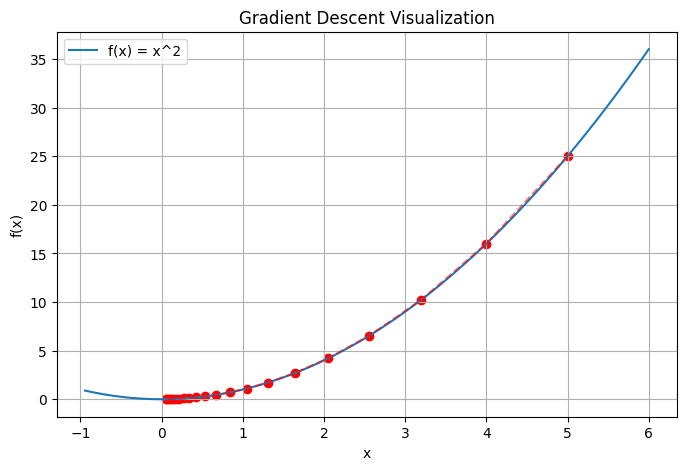

In [ ]:


x_curve = np.linspace(min(x_points)-1, max(x_points)+1, 100)
y_curve = f(x_curve)

plt.figure(figsize=(8,5))
plt.plot(x_curve, y_curve, label="f(x) = x^2")
plt.scatter(x_points, y_points, color='red')
plt.plot(x_points, y_points, color='red', linestyle='--', alpha=0.5)
plt.title("Gradient Descent Visualization")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

Iteration 1: x = [ 1. -2.], ||grad|| = 14.142135623730951


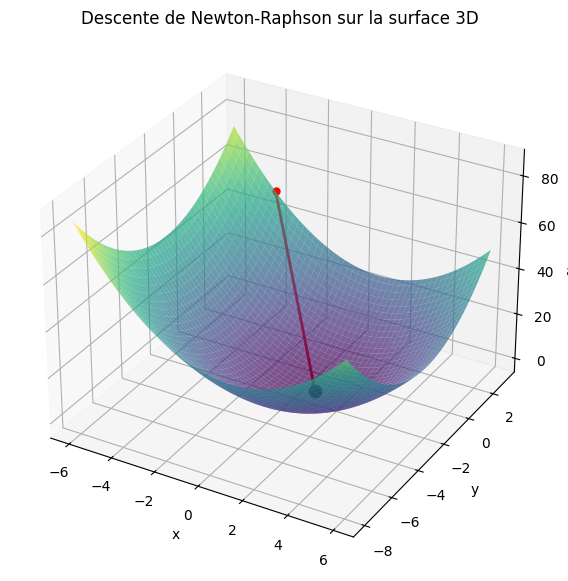

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(X):
    x, y = X
    return (x-1)**2 + (y+2)**2

def grad_f(X):
    x, y = X
    return np.array([2*(x-1), 2*(y+2)])

def hessian_f(X):
    return np.array([[2, 0],
                     [0, 2]])

def newton_raphson_multivariable(f, grad_f, hessian_f, x0, tol=1e-6, max_iter=30):
    x = np.array(x0, dtype=float)
    chemin = [x.copy()]

    for k in range(max_iter):
        gk = grad_f(x)
        if np.linalg.norm(gk) < tol:
            break

        Hk = hessian_f(x)

        try:
            pk = -np.linalg.inv(Hk) @ gk
        except:
            print("Hessienne non inversible!")
            break

        x_new = x + pk
        chemin.append(x_new.copy())

        if np.linalg.norm(x_new - x) < tol:
            x = x_new
            break

        x = x_new

        print(f"Iteration {k+1}: x = {x}, ||grad|| = {np.linalg.norm(gk)}")

    return x, np.array(chemin)

x0 = [-4, 3]
xmin, chemin = newton_raphson_multivariable(f, grad_f, hessian_f, x0)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x_vals = np.linspace(-6, 6, 200)
y_vals = np.linspace(-8, 3, 200)
X, Y = np.meshgrid(x_vals, y_vals)
Z = (X-1)**2 + (Y+2)**2

ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)

chemin_z = np.array([f(p) for p in chemin])
ax.plot(chemin[:,0], chemin[:,1], chemin_z, 'r-o', linewidth=2, markersize=5)

ax.scatter(1, -2, 0, color='black', s=80)

ax.set_title("Descente de Newton-Raphson sur la surface 3D")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
plt.show()


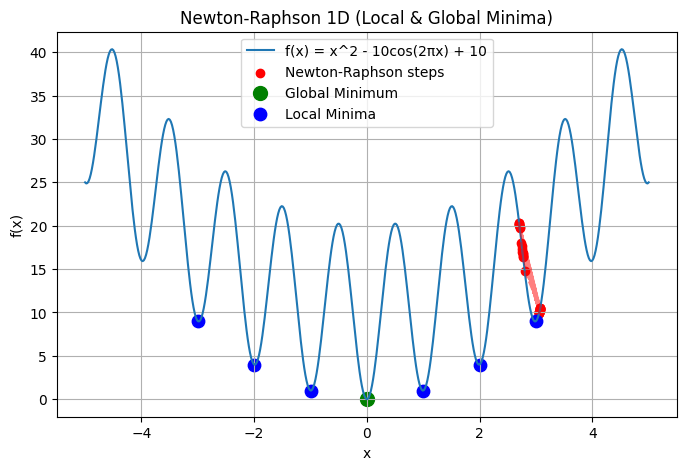

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    return x**2 - 10*np.cos(2*np.pi*x)

def df(x):
    return 2*x + 20*np.pi*np.sin(2*np.pi*x)


def newton_1D(x0, tol=1e-6, max_iter=30):
    x = x0
    x_points = [x]
    y_points = [f(x)]

    for i in range(max_iter):
        dfx = df(x)
        if dfx == 0:
            break
        x_new = x - f(x)/dfx
        x_points.append(x_new)
        y_points.append(f(x_new))
        if abs(x_new - x) < tol:
            break
        x = x_new
    return x, x_points, y_points


x0 = 2.8
root, x_points, y_points = newton_1D(x0)

x_curve = np.linspace(-5, 5, 500)
y_curve = f(x_curve)

plt.figure(figsize=(8,5))
plt.plot(x_curve, y_curve, label="f(x) = x^2 - 10cos(2πx) + 10")
plt.scatter(x_points, y_points, color='red', label="Newton-Raphson steps")
plt.plot(x_points, y_points, color='red', linestyle='--', alpha=0.5)


x_global = [0]
y_global = f(np.array(x_global))
plt.scatter(x_global, y_global, color='green', s=100, label="Global Minimum")


x_local = [-1, 1, -2, 2, -3, 3]
y_local = f(np.array(x_local))
plt.scatter(x_local, y_local, color='blue', s=80, label="Local Minima")

plt.title("Newton-Raphson 1D (Local & Global Minima)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()


Modele Pyomo pour PNL ( Sans Contraint )

resolution utiliser la  bib  scypy pour PNL (Vessel problem )

Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: 301.56042275158643
            Iterations: 9
            Function evaluations: 27
            Gradient evaluations: 5

================ RÉSULTATS =================

Convergence réussie : False
Message du solveur  : Positive directional derivative for linesearch
Nombre d'itérations : 9
Valeur minimale du coût : 301.56042275158643

Variables optimales :
Ts (épaisseur calotte) = 0.076642
Th (épaisseur virole)  = 0.175453
R  (rayon intérieur)   = 18.390938
L  (longueur cylindre) = 199.999667

Volume final = 212513.68


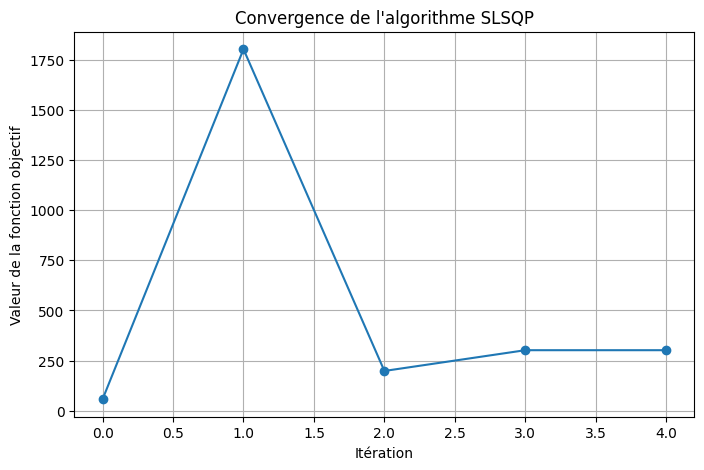

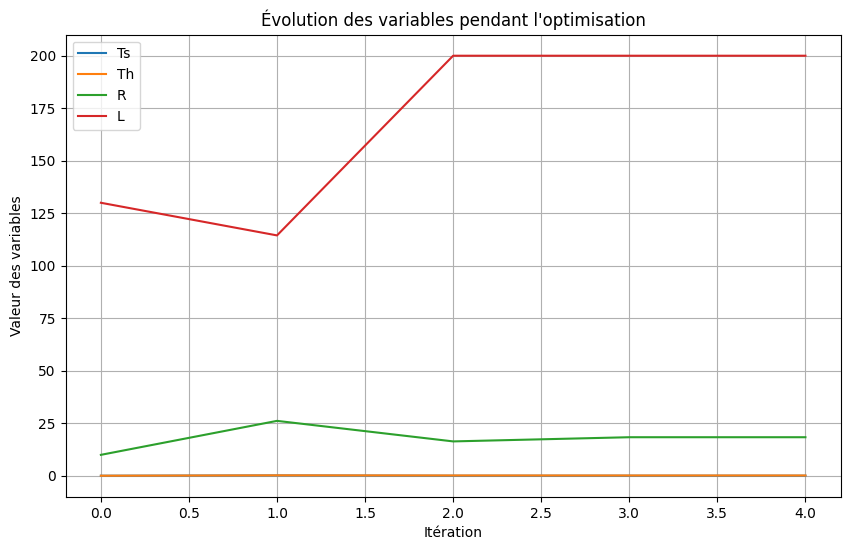

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


def objective(x):
    Ts, Th, R, L = x
    cost = (
        0.6224 * Ts * R * L
        + 1.7781 * Th * (R**2) * (Ts**2) * L
        + 19.84 * (Ts**2) * R
    )
    return cost


constraints = [
    {'type': 'ineq', 'fun': lambda x: x[0] - 0.0193*x[2]},  # Ts >= 0.0193*R
    {'type': 'ineq', 'fun': lambda x: x[1] - 0.00954*x[2]}, # Th >= 0.00954*R
    {'type': 'ineq', 'fun': lambda x: np.pi*x[2]**2*x[3] - 129600000}  # Volume >= 129600000
]

bounds = [
    (0.0625, None),  # Ts >= 0.0625
    (0.0625, None),  # Th >= 0.0625
    (10.0, 200.0),
    (10.0, 200.0)
]


x0 = [0.5, 0.5, 50.0, 50.0]  # Volume >= 129600000


history_cost = []
history_Ts = []
history_Th = []
history_R = []
history_L = []

def callback_full(xk):
    history_cost.append(objective(xk))
    history_Ts.append(xk[0])
    history_Th.append(xk[1])
    history_R.append(xk[2])
    history_L.append(xk[3])

result = minimize(
    objective,
    x0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    callback=callback_full,
    options={
        'maxiter': 500,
        'ftol': 1e-6,
        'disp': True
    }
)


print("\n================ RÉSULTATS =================\n")
print("Convergence réussie :", result.success)
print("Message du solveur  :", result.message)
print("Nombre d'itérations :", result.nit)
print("Valeur minimale du coût :", result.fun)

print("\nVariables optimales :")
print(f"Ts (épaisseur calotte) = {result.x[0]:.6f}")
print(f"Th (épaisseur virole)  = {result.x[1]:.6f}")
print(f"R  (rayon intérieur)   = {result.x[2]:.6f}")
print(f"L  (longueur cylindre) = {result.x[3]:.6f}")

volume_final = np.pi * result.x[2]**2 * result.x[3]
print(f"\nVolume final = {volume_final:.2f}")


plt.figure(figsize=(8, 5))
plt.plot(history_cost, marker='o')
plt.xlabel("Itération")
plt.ylabel("Valeur de la fonction objectif")
plt.title("Convergence de l'algorithme SLSQP")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_Ts, label='Ts')
plt.plot(history_Th, label='Th')
plt.plot(history_R, label='R')
plt.plot(history_L, label='L')
plt.xlabel("Itération")
plt.ylabel("Valeur des variables")
plt.title("Évolution des variables pendant l'optimisation")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


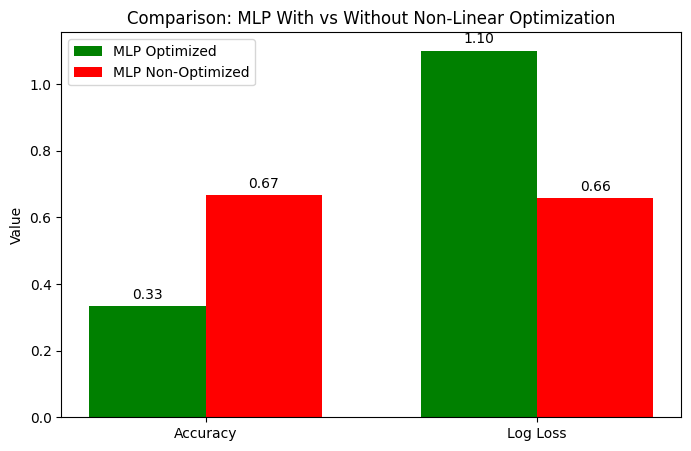

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss
import numpy as np
import matplotlib.pyplot as plt


texts = ["I love this product", "I hate it", "Amazing service", "Worst experience",
         "Very happy", "Not satisfied", "Excellent quality", "Terrible experience"]
labels = [1,0,1,0,1,0,1,0]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texts)
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



mlp_opt = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=500, random_state=42)
mlp_opt.fit(X_train, y_train)

y_pred_opt = mlp_opt.predict(X_test)
y_proba_opt = mlp_opt.predict_proba(X_test)
acc_opt = accuracy_score(y_test, y_pred_opt)
loss_opt = log_loss(y_test, y_proba_opt)



mlp_no_opt = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1, random_state=42, warm_start=True)
mlp_no_opt.fit(X_train[:1], y_train[:1])

y_pred_no_opt = mlp_no_opt.predict(X_test)
y_proba_no_opt = mlp_no_opt.predict_proba(X_test)
acc_no_opt = accuracy_score(y_test, y_pred_no_opt)
loss_no_opt = log_loss(y_test, y_proba_no_opt)


metrics = ["Accuracy", "Log Loss"]
optimized = [acc_opt, loss_opt]
non_optimized = [acc_no_opt, loss_no_opt]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, optimized, width, label='MLP Optimized', color='green')
rects2 = ax.bar(x + width/2, non_optimized, width, label='MLP Non-Optimized', color='red')


ax.set_ylabel('Value')
ax.set_title('Comparison: MLP With vs Without Non-Linear Optimization')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0,3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.show()
